# Inter-Uni Datathon — Stream 2: Beijing Multi-Site Air Quality
## Complete Exploratory Data Analysis (EDA)

**Goal:** understand the structure, quality, temporal behaviour and predictive signal in the competition data before feature engineering and modelling.

This notebook covers:

- dataset structure and time coverage;
- missing values and data quality;
- target distribution and extreme pollution events;
- persistence / naive baseline signal;
- pollutant and meteorological relationships;
- hourly, monthly and station-level patterns;
- wind-direction effects;
- train–test distribution shift;
- validation leakage risks;
- modelling implications and recommended next steps.

> **Important:** the test set begins immediately after the training period. This is a forecasting problem. Random train/validation splitting would leak future distributional information and produce an unrealistically optimistic estimate.

In [1]:
# Imports and plotting setup
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

/Users/yo/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Load the data

In [2]:
# File loading
train = pd.read_csv("data/train_cleaned.csv")
test = pd.read_csv("data/test_cleaned.csv")

train["observation_timestamp"] = pd.to_datetime(train["observation_timestamp"])
test["observation_timestamp"] = pd.to_datetime(test["observation_timestamp"])

print("Train shape:", train.shape)
print("Test shape: ", test.shape)

Train shape: (360954, 20)
Test shape:  (51063, 19)


In [3]:
display(train.head())
display(test.head())

,id,observation_timestamp,station,year,month,day,hour,current_PM2_5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,PM2_5_next_hour
0,AQ_249AF8D9D878,2013-03-01,Aotizhongxin,2013,3,1,0,4.000,4.000,4.000,7.000,300.000,77.000,-0.700,"1,023.000",-18.800,0.000,NNW,4.400,8.000
1,AQ_EB620EFFEEC8,2013-03-01,Changping,2013,3,1,0,3.000,6.000,13.000,7.000,300.000,85.000,-2.300,"1,020.800",-19.700,0.000,E,0.500,3.000
2,AQ_27EEFC23DFA3,2013-03-01,Dingling,2013,3,1,0,4.000,4.000,3.000,49.488,200.000,82.000,-2.300,"1,020.800",-19.700,0.000,E,0.500,7.000
3,AQ_C2DEB5BEFD7E,2013-03-01,Dongsi,2013,3,1,0,9.000,9.000,3.000,17.000,300.000,89.000,-0.500,"1,024.500",-21.400,0.000,NNW,5.700,4.000
4,AQ_8B32BEDFDF0D,2013-03-01,Guanyuan,2013,3,1,0,4.000,4.000,14.000,20.000,300.000,69.000,-0.700,"1,023.000",-18.800,0.000,NNW,4.400,4.000


,id,observation_timestamp,station,year,month,day,hour,current_PM2_5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
0,AQ_943859884785,2016-08-31 23:00:00,Aotizhongxin,2016,8,31,23,6.000,18.000,2.000,48.000,500.000,44.000,27.700,991.200,-2.200,0.000,NW,1.100
1,AQ_C9BF613B47E2,2016-08-31 23:00:00,Changping,2016,8,31,23,6.000,29.000,2.000,53.000,600.000,27.000,24.000,987.000,1.600,0.000,NNW,0.900
2,AQ_FF735F28FE3F,2016-08-31 23:00:00,Dingling,2016,8,31,23,15.000,23.000,2.000,3.000,200.000,42.000,24.000,987.000,1.600,0.000,NNW,0.900
3,AQ_E1F8BCA3B667,2016-08-31 23:00:00,Dongsi,2016,8,31,23,9.000,27.000,2.000,41.000,300.000,43.000,27.700,991.200,-2.200,0.000,NW,1.100
4,AQ_7E9470275B90,2016-08-31 23:00:00,Guanyuan,2016,8,31,23,8.000,31.000,2.000,43.000,200.000,38.000,27.700,991.200,-2.200,0.000,NW,1.100


### Interpretation

- The training set contains **360,954 observations and 20 columns**.
- The test set contains **51,063 observations and 19 columns**.
- The extra training column is the prediction target: **`PM2_5_next_hour`**.
- Each row contains a station, timestamp, current pollutant readings, meteorological variables and a one-hour-ahead PM2.5 target.

## 2. Schema, uniqueness and temporal coverage

In [4]:
# Column schema and basic quality checks
schema = pd.DataFrame({
    "dtype_train": train.dtypes.astype(str),
    "missing_train": train.isna().sum(),
    "missing_%_train": train.isna().mean().mul(100),
})
schema["missing_test"] = test.isna().sum().reindex(schema.index)
schema["missing_%_test"] = test.isna().mean().mul(100).reindex(schema.index)
display(schema)

print("Unique stations:", train["station"].nunique())
print(sorted(train["station"].unique()))
print()
print("Train time:", train["observation_timestamp"].min(), "to", train["observation_timestamp"].max())
print("Test time: ", test["observation_timestamp"].min(), "to", test["observation_timestamp"].max())
print()
print("Exact duplicate train rows:", train.duplicated().sum())
print("Duplicated train IDs:", train["id"].duplicated().sum())
print("Duplicated test IDs: ", test["id"].duplicated().sum())

,dtype_train,missing_train,missing_%_train,missing_test,missing_%_test
id,object,0,0.000,0.000,0.000
observation_timestamp,datetime64[ns],0,0.000,0.000,0.000
station,object,0,0.000,0.000,0.000
year,int64,0,0.000,0.000,0.000
month,int64,0,0.000,0.000,0.000
day,int64,0,0.000,0.000,0.000
hour,int64,0,0.000,0.000,0.000
current_PM2_5,float64,0,0.000,0.000,0.000
PM10,float64,0,0.000,0.000,0.000
SO2,float64,0,0.000,0.000,0.000


Unique stations: 12
['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']

Train time: 2013-03-01 00:00:00 to 2016-08-31 22:00:00
Test time:  2016-08-31 23:00:00 to 2017-02-28 22:00:00

Exact duplicate train rows: 0
Duplicated train IDs: 0
Duplicated test IDs:  0


### Interpretation

- There are **12 monitoring stations**.
- Train covers **2013-03-01 00:00:00 to 2016-08-31 22:00:00**.
- Test starts at **2016-08-31 23:00:00** and continues to **2017-02-28 22:00:00**.
- Therefore, the public competition task is a **forward temporal holdout**, not an IID random-sampling problem.
- There are no duplicated IDs or fully duplicated rows in the training data, so each supplied observation is uniquely identified.

## 3. Missing-value check
Missing value should be handled in the Data Cleaing notebook, have a last check

In [6]:
# Missing-value summary
def missing_summary(df):
    out = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100
    })
    return out[out["missing_count"] > 0].sort_values("missing_pct", ascending=False)

train_missing = missing_summary(train)
test_missing = missing_summary(test)

print("TRAIN")
display(train_missing)
print("TEST")
display(test_missing)

TRAIN


,missing_count,missing_pct


TEST


,missing_count,missing_pct


## 4. Descriptive statistics

In [7]:
# Numeric descriptive statistics
numeric_cols = train.select_dtypes(include=np.number).columns.tolist()
display(train[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
year,"360,954.000","2,014.426",1.052,"2,013.000","2,013.000","2,013.000","2,014.000","2,014.000","2,015.000","2,016.000","2,016.000","2,016.000"
month,"360,954.000",6.370,3.278,1.000,1.000,1.000,4.000,6.000,9.000,12.000,12.000,12.000
day,"360,954.000",15.749,8.804,1.000,1.000,2.000,8.000,16.000,23.000,30.000,31.000,31.000
hour,"360,954.000",11.493,6.935,0.000,0.000,1.000,5.000,11.000,18.000,22.000,23.000,23.000
current_PM2_5,"360,954.000",77.991,77.353,2.000,3.000,6.000,21.000,55.000,108.000,234.000,352.000,999.000
PM10,"360,954.000",103.524,88.678,2.000,5.000,10.000,37.000,83.000,143.000,273.000,403.000,999.000
SO2,"360,954.000",16.376,22.250,0.286,1.428,2.000,3.000,8.000,20.000,63.000,106.000,500.000
NO2,"360,954.000",49.488,34.015,1.026,2.000,8.000,23.000,43.000,69.000,114.000,153.250,290.000
CO,"360,954.000","1,184.508","1,061.368",100.000,100.000,200.000,500.000,900.000,"1,400.000","3,200.000","5,500.000","10,000.000"
O3,"360,954.000",60.843,57.422,0.214,1.000,2.000,14.000,50.000,85.000,182.000,248.000,"1,071.000"


### Interpretation

The pollutant variables have very different scales and several are strongly right-skewed. PM2.5 in particular contains rare but very large pollution episodes. These extremes are likely to dominate squared-error metrics and should not be removed simply because they look like statistical outliers: many represent real high-pollution events.

## 5. Target distribution: `PM2_5_next_hour`

In [8]:
# Target summary
target = "PM2_5_next_hour"
target_stats = train[target].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
display(target_stats.to_frame("value"))
print("Skewness:", train[target].skew())

,value
count,"360,954.000"
mean,78.044
std,77.778
min,2.000
1%,3.000
5%,6.000
25%,21.000
50%,55.000
75%,108.000
95%,235.000


Skewness: 2.013255422324208


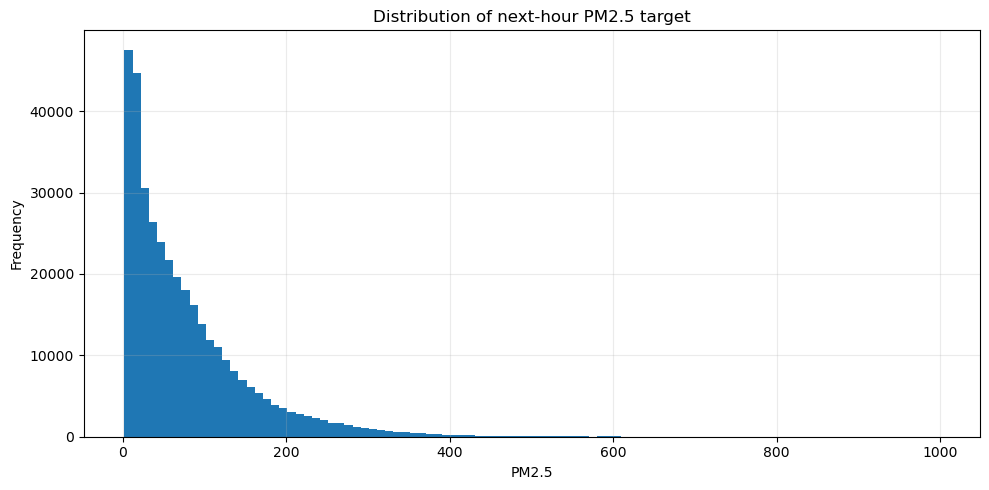

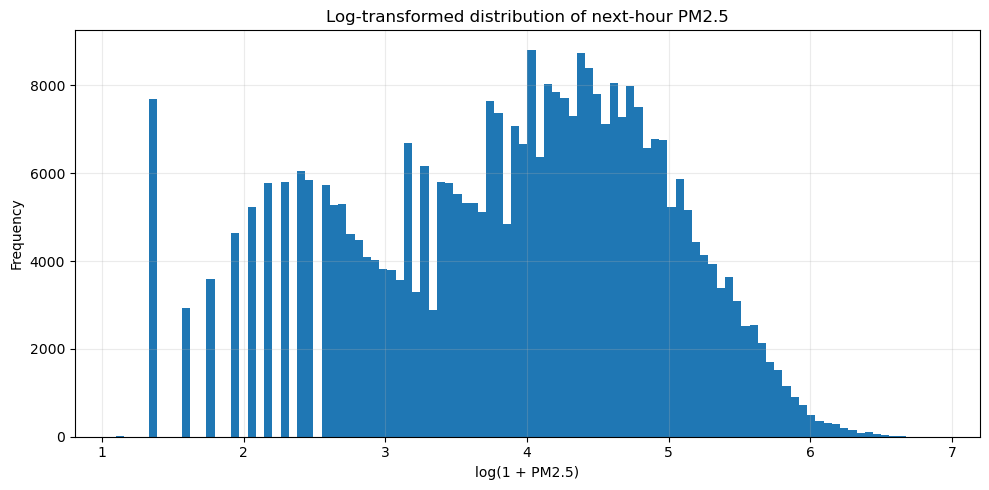

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train[target].dropna(), bins=100)
ax.set_title("Distribution of next-hour PM2.5 target")
ax.set_xlabel("PM2.5")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log1p(train[target].dropna()), bins=100)
ax.set_title("Log-transformed distribution of next-hour PM2.5")
ax.set_xlabel("log(1 + PM2.5)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

### Interpretation

- Target **median ≈ 55**, while the **mean ≈ 78**, confirming strong right skew.
- The 95th percentile is around **235**, the 99th percentile around **354**, and the maximum is **999**.
- This means a small number of severe pollution episodes can have a very large influence on RMSE-like metrics.
- A log view is useful for EDA, but whether to train on `log1p(target)` should be decided against the actual competition metric. If the leaderboard is based on error in the original PM2.5 scale, direct target modelling may still be preferable.

## 6. The strongest baseline: persistence

For one-hour-ahead forecasting, the first baseline should be:

> **next-hour PM2.5 ≈ current PM2.5**

This provides a surprisingly strong reference point and tells us how much value more complex models must add.

Correlation(current PM2.5, next-hour PM2.5): 0.9634
Persistence baseline MAE:  10.772
Persistence baseline RMSE: 21.002


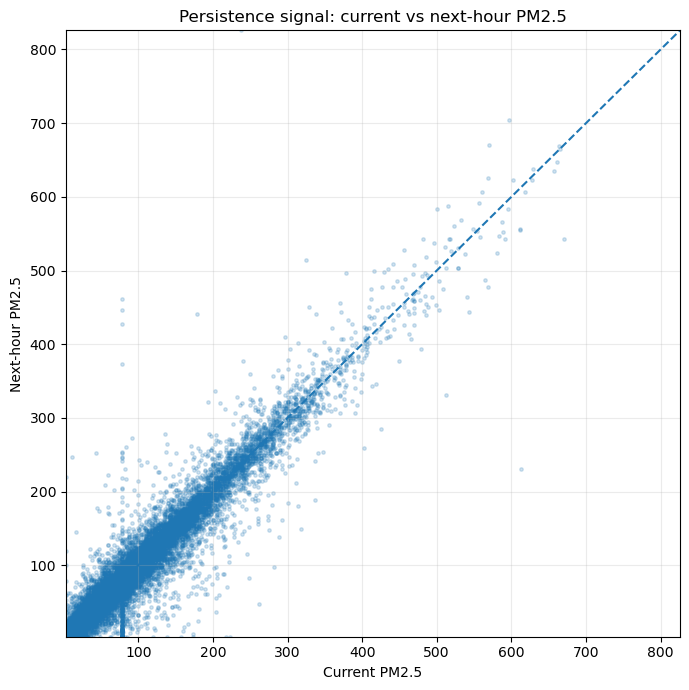

In [10]:
# Persistence relationship
valid = train[["current_PM2_5", target]].dropna()

corr_persistence = valid.corr().iloc[0, 1]
mae_persistence = np.mean(np.abs(valid[target] - valid["current_PM2_5"]))
rmse_persistence = np.sqrt(np.mean((valid[target] - valid["current_PM2_5"]) ** 2))

print(f"Correlation(current PM2.5, next-hour PM2.5): {corr_persistence:.4f}")
print(f"Persistence baseline MAE:  {mae_persistence:.3f}")
print(f"Persistence baseline RMSE: {rmse_persistence:.3f}")

sample = valid.sample(min(25000, len(valid)), random_state=42)
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(sample["current_PM2_5"], sample[target], s=6, alpha=0.2)
lims = [
    min(sample["current_PM2_5"].min(), sample[target].min()),
    max(sample["current_PM2_5"].max(), sample[target].max())
]
ax.plot(lims, lims, linestyle="--")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Current PM2.5")
ax.set_ylabel("Next-hour PM2.5")
ax.set_title("Persistence signal: current vs next-hour PM2.5")
plt.tight_layout()
plt.show()

### Interpretation

- `current_PM2_5` has approximately **0.968 Pearson correlation** with `PM2_5_next_hour`.
- Points cluster closely around the 45-degree line, demonstrating strong short-term persistence.
- Any competitive model should be evaluated against this naive baseline. A complex model that cannot materially improve it is not useful.
- The remaining modelling problem is mainly to predict **changes away from persistence**, especially during rapid pollution build-up or clearing episodes.

## 7. Correlation between numeric features and the target

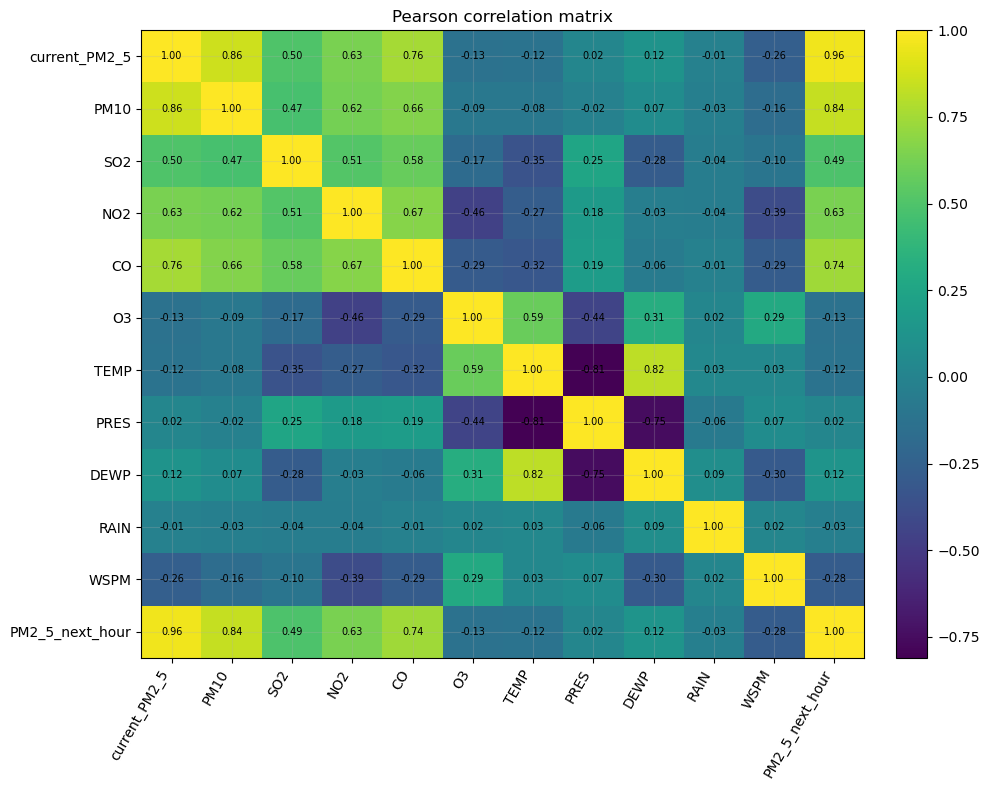

,corr_with_target
current_PM2_5,0.963
PM10,0.843
CO,0.741
NO2,0.634
SO2,0.495
WSPM,-0.280
O3,-0.131
DEWP,0.123
TEMP,-0.122
RAIN,-0.028


In [11]:
# Correlation matrix
model_numeric = [
    "current_PM2_5", "PM10", "SO2", "NO2", "CO", "O3",
    "TEMP", "PRES", "DEWP", "RAIN", "WSPM", target
]
corr_matrix = train[model_numeric].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, aspect="auto")
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=60, ha="right")
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Pearson correlation matrix")
plt.tight_layout()
plt.show()

target_corr = corr_matrix[target].drop(target).sort_values(key=np.abs, ascending=False)
display(target_corr.to_frame("corr_with_target"))

### Interpretation

Approximate linear correlations with next-hour PM2.5 show a clear ranking:

- `current_PM2_5`: **0.968** — overwhelmingly strongest single predictor.
- `PM10`: **0.848** — another strong particulate-matter signal.
- `CO`: **0.762** and `NO2`: **0.643** — strong co-pollution / combustion signals.
- `SO2`: **0.499** — moderate positive relationship.
- `WSPM`: about **−0.280** — higher wind speed tends to disperse pollution.
- `O3` and `TEMP` have modest negative linear correlations; their effects are likely nonlinear and season-dependent.

Correlation does **not** imply causality, and a nonlinear tree/boosting model can extract signal that Pearson correlation misses.

## 8. Temporal patterns

We derive day-of-week only for EDA; all timestamp-based features can be regenerated safely from the observation time.

In [12]:
# Add EDA-only temporal features
eda = train.copy()
eda["weekday"] = eda["observation_timestamp"].dt.dayofweek
eda["date"] = eda["observation_timestamp"].dt.date
eda["year_month"] = eda["observation_timestamp"].dt.to_period("M").astype(str)

hourly = eda.groupby("hour")[target].agg(["mean", "median", "count"])
monthly = eda.groupby("month")[target].agg(["mean", "median", "count"])
weekday = eda.groupby("weekday")[target].agg(["mean", "median", "count"])

display(hourly)
display(monthly)
display(weekday)

,mean,median,count
hour,,,
0,83.856,60.000,15119
1,82.031,59.000,15110
2,79.808,58.000,15083
3,77.441,57.000,15110
4,74.693,54.000,15109
5,73.001,53.000,15118
6,72.456,52.000,15106
7,74.194,53.000,15127
8,75.831,55.000,15082


,mean,median,count
month,,,
1,87.085,62.000,26415
2,93.548,50.000,24014
3,94.726,70.000,35293
4,72.726,61.000,33698
5,63.045,50.000,34710
6,69.096,53.000,33743
7,71.752,59.000,34717
8,53.422,41.000,35203
9,63.919,50.000,25514


,mean,median,count
weekday,,,
0,73.819,52.000,51455
1,75.838,54.000,51354
2,73.931,53.000,51476
3,79.363,55.000,51259
4,82.384,57.000,51712
5,83.367,58.000,51840
6,77.550,54.000,51858


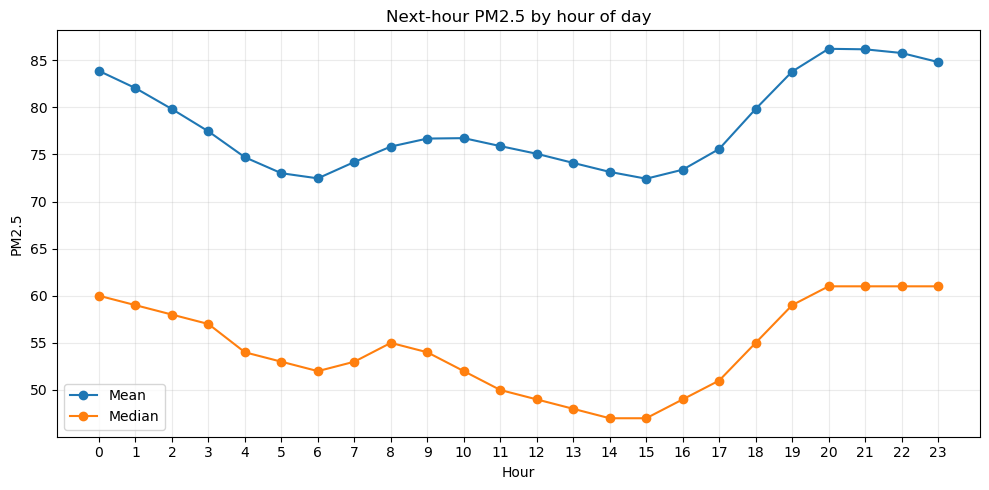

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hourly.index, hourly["mean"], marker="o", label="Mean")
ax.plot(hourly.index, hourly["median"], marker="o", label="Median")
ax.set_title("Next-hour PM2.5 by hour of day")
ax.set_xlabel("Hour")
ax.set_ylabel("PM2.5")
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation — hour of day

- PM2.5 is not constant over the day.
- In this training sample, the **highest mean is around hour 20 (~86.2)** and the **lowest mean around hour 15 (~72.4)**.
- The pattern is moderate rather than dominant, so `hour` should be treated as a contextual feature rather than a standalone predictor.
- Cyclical encoding (`sin(hour)`, `cos(hour)`) can help linear/neural models represent the continuity between 23:00 and 00:00. Tree models can usually use integer hour directly.

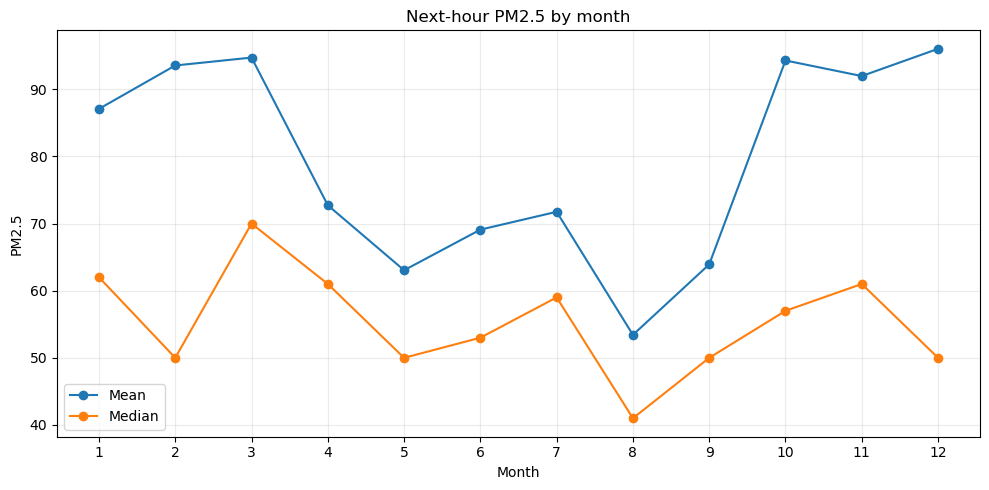

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly.index, monthly["mean"], marker="o", label="Mean")
ax.plot(monthly.index, monthly["median"], marker="o", label="Median")
ax.set_title("Next-hour PM2.5 by month")
ax.set_xlabel("Month")
ax.set_ylabel("PM2.5")
ax.set_xticks(range(1, 13))
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation — seasonality

- Strong seasonal structure is visible. Several cooler-season months have higher mean pollution than summer months.
- December has one of the highest training means (**~96 PM2.5**).
- Month therefore contains meaningful predictive information, but the test period spans September–February, so validation should mimic this future-season forecasting setting.
- Interactions between season and weather (temperature, pressure, dew point, wind) are likely important.

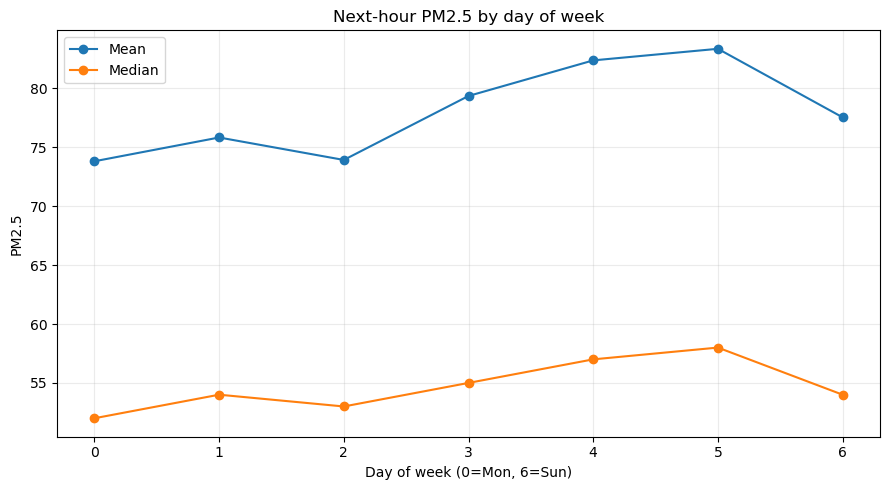

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(weekday.index, weekday["mean"], marker="o", label="Mean")
ax.plot(weekday.index, weekday["median"], marker="o", label="Median")
ax.set_title("Next-hour PM2.5 by day of week")
ax.set_xlabel("Day of week (0=Mon, 6=Sun)")
ax.set_ylabel("PM2.5")
ax.set_xticks(range(7))
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation — weekday

Day-of-week differences are much smaller than the dominant persistence and seasonal effects. The feature may still provide incremental signal, particularly if traffic and activity patterns differ between weekdays and weekends.

## 9. Station-level differences

In [16]:
# Station statistics
station_stats = (
    eda.groupby("station")[target]
    .agg(["count", "mean", "median", "std", "max"])
    .sort_values("mean", ascending=False)
)
display(station_stats)

,count,mean,median,std,max
station,,,,,
Dongsi,30079,83.676,60.000,82.628,737.000
Nongzhanguan,30175,82.671,58.000,82.945,844.000
Wanshouxigong,30091,82.363,59.000,81.619,999.000
Wanliu,30393,82.182,59.000,79.468,957.000
Gucheng,30166,81.605,59.000,78.461,770.000
Aotizhongxin,29846,81.118,58.000,79.190,898.000
Guanyuan,30199,80.903,59.000,77.586,680.000
Tiantan,30102,80.118,58.000,77.535,821.000
Shunyi,29940,77.911,54.000,78.406,941.000


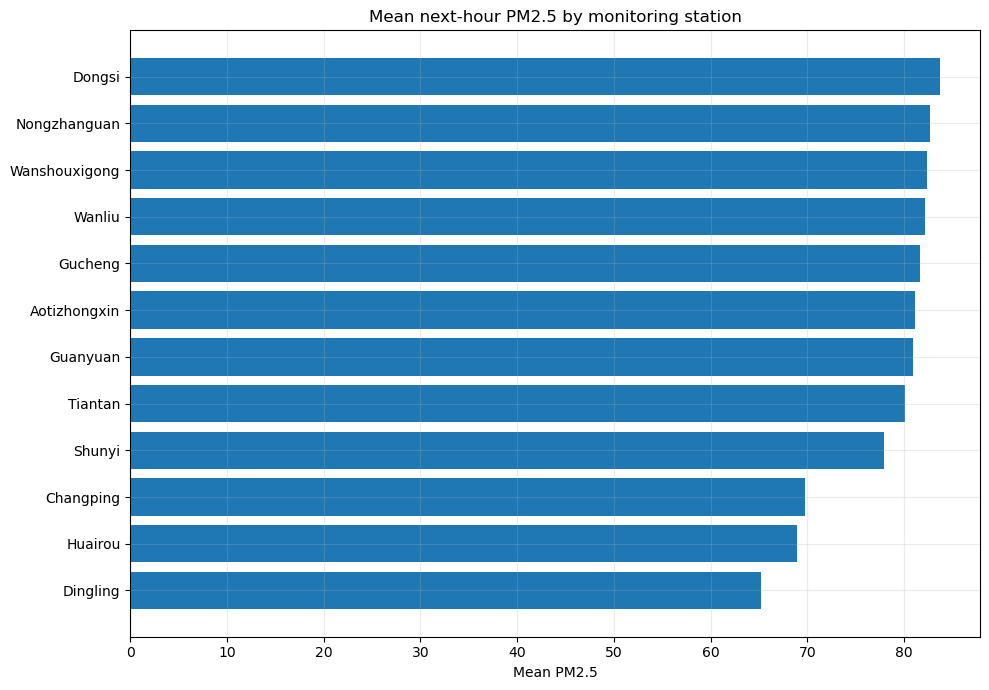

In [17]:
station_plot = station_stats.sort_values("mean")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(station_plot.index, station_plot["mean"])
ax.set_title("Mean next-hour PM2.5 by monitoring station")
ax.set_xlabel("Mean PM2.5")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Interpretation

- Station identity matters: average pollution levels differ across the 12 monitoring sites.
- `Dongsi`, `Nongzhanguan`, `Wanshouxigong`, `Wanliu` and `Gucheng` are among the higher-mean stations in the training period.
- The differences support keeping `station` as a model feature rather than pooling all observations as if they came from one homogeneous sensor.
- For linear models, use one-hot encoding. For tree boosting, categorical handling or encoded station features can be tested.
- Station-specific lag/rolling features are especially important because measurements must never be mixed across stations.

## 10. Meteorology and PM2.5

Wind is especially relevant because stronger air movement can disperse particulate matter.

,mean_wind,mean_target,median_target,count
wind_bin,,,,
"(-0.001, 0.6]",0.344,100.766,76.000,47980
"(0.6, 0.8]",0.752,99.209,74.000,31626
"(0.8, 1.0]",0.951,97.472,74.000,36634
"(1.0, 1.2]",1.150,93.439,70.000,37227
"(1.2, 1.4]",1.348,86.625,65.000,33170
"(1.4, 1.7]",1.594,79.833,58.000,40074
"(1.7, 2.0]",1.893,71.288,52.000,29503
"(2.0, 2.5]",2.280,62.605,44.000,35010
"(2.5, 3.4]",2.946,49.270,31.000,35011


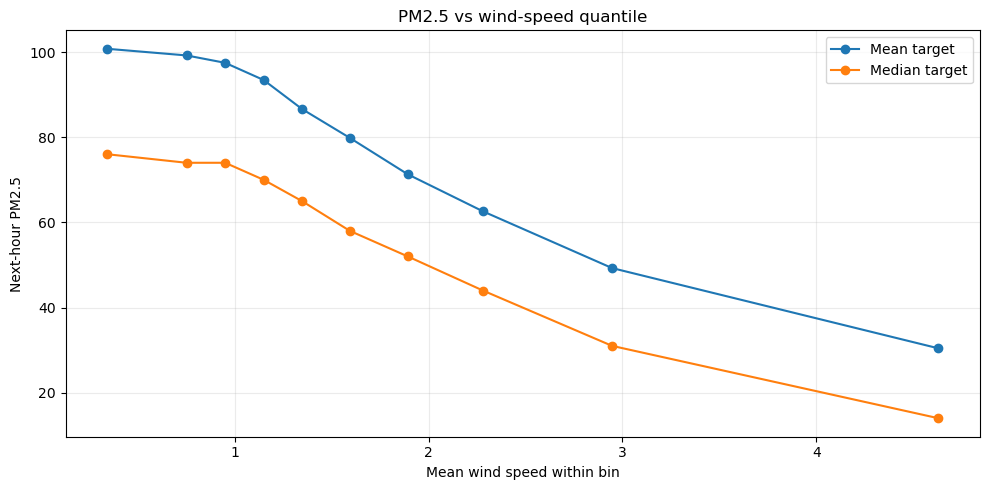

In [18]:
# Relationship between wind speed and target using quantile bins
tmp = eda[["WSPM", target]].dropna().copy()
tmp["wind_bin"] = pd.qcut(tmp["WSPM"], q=10, duplicates="drop")

wind_bins = tmp.groupby("wind_bin", observed=True).agg(
    mean_wind=("WSPM", "mean"),
    mean_target=(target, "mean"),
    median_target=(target, "median"),
    count=(target, "size")
)

display(wind_bins)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(wind_bins["mean_wind"], wind_bins["mean_target"], marker="o", label="Mean target")
ax.plot(wind_bins["mean_wind"], wind_bins["median_target"], marker="o", label="Median target")
ax.set_title("PM2.5 vs wind-speed quantile")
ax.set_xlabel("Mean wind speed within bin")
ax.set_ylabel("Next-hour PM2.5")
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation

- Wind speed has a negative linear correlation with target (about **−0.28**).
- The binned relationship shows the practical pattern more clearly: stronger winds generally correspond to lower next-hour PM2.5.
- This suggests useful nonlinear thresholds and interactions. For example, wind may matter more when current pollution is already high.

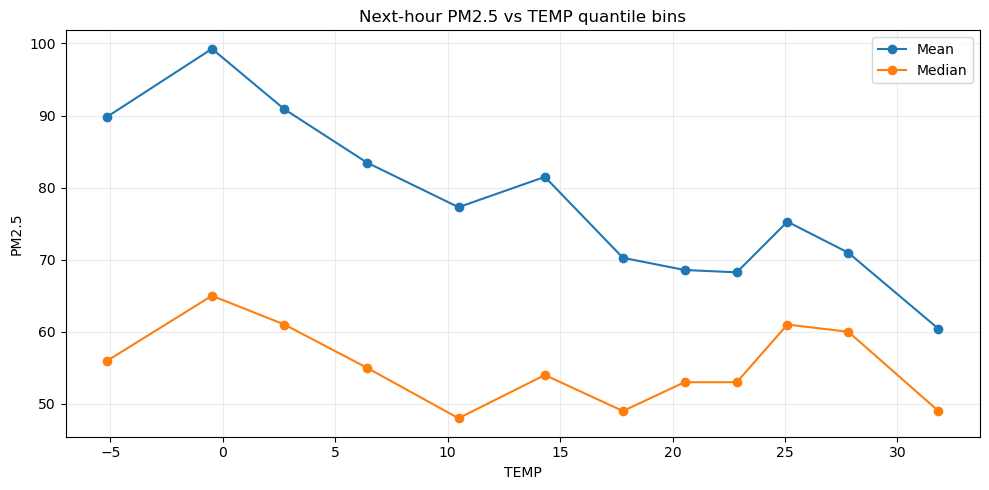

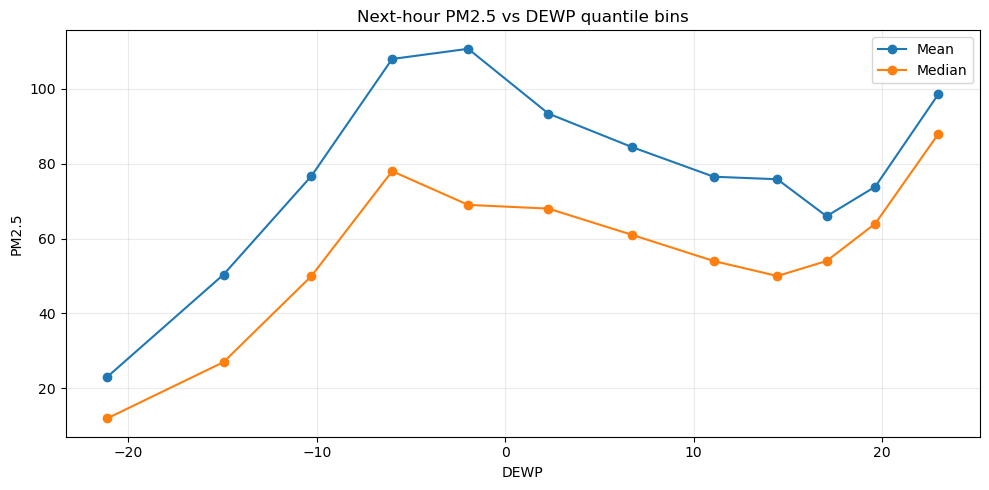

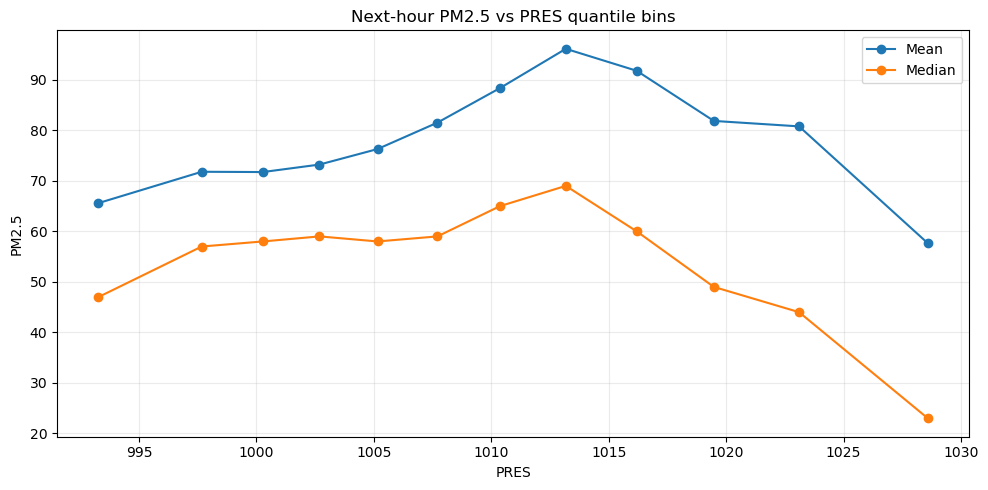

In [19]:
# Temperature and dew point binned relationships
for col in ["TEMP", "DEWP", "PRES"]:
    tmp = eda[[col, target]].dropna().copy()
    tmp["bin"] = pd.qcut(tmp[col], q=12, duplicates="drop")
    b = tmp.groupby("bin", observed=True).agg(
        x=(col, "mean"),
        target_mean=(target, "mean"),
        target_median=(target, "median"),
        count=(target, "size")
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(b["x"], b["target_mean"], marker="o", label="Mean")
    ax.plot(b["x"], b["target_median"], marker="o", label="Median")
    ax.set_title(f"Next-hour PM2.5 vs {col} quantile bins")
    ax.set_xlabel(col)
    ax.set_ylabel("PM2.5")
    ax.legend()
    plt.tight_layout()
    plt.show()

### Interpretation

Temperature, dew point and pressure do not have purely linear relationships with PM2.5. Their binned curves show why a nonlinear model is appropriate. They should be retained even when their simple Pearson correlations appear modest, because weather variables interact with season, wind and existing pollutant levels.

## 11. Wind direction

,count,mean,median
wd,,,
ESE,21223,100.601,80.000
E,26286,98.977,76.000
SE,16766,96.260,79.000
ENE,29634,94.851,69.000
Missing,793,93.342,64.000
SSE,15734,92.078,76.000
S,17108,87.586,70.000
NE,33947,83.316,54.000
SSW,20336,82.967,68.000


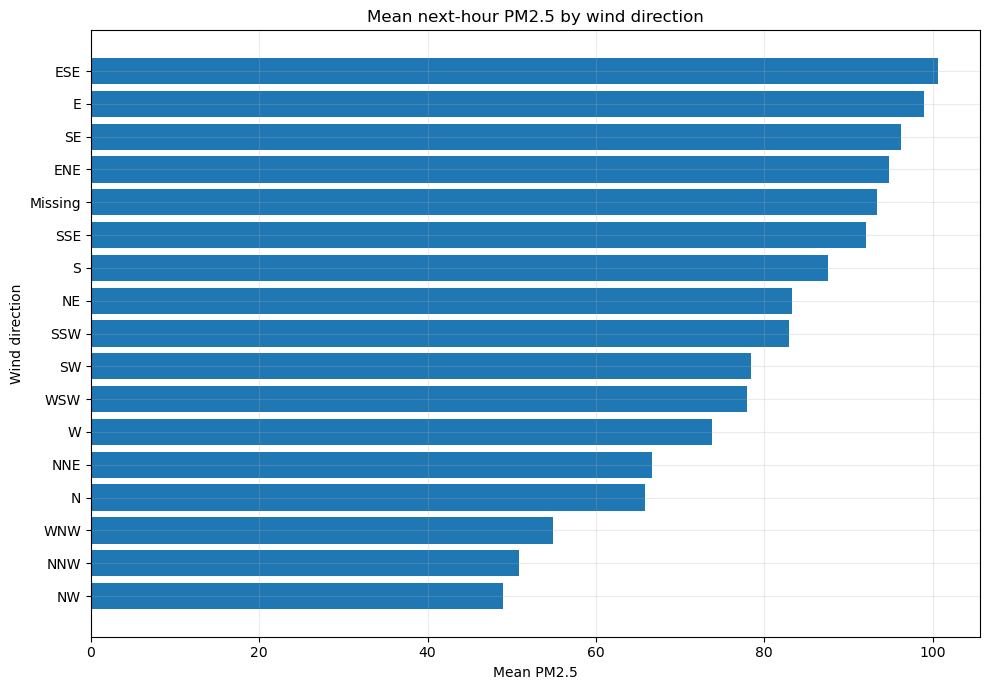

In [20]:
# Wind direction frequency and pollution level
wd_stats = (
    eda.groupby("wd", dropna=False)[target]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)
display(wd_stats)

wd_plot = wd_stats.dropna().sort_values("mean")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(wd_plot.index.astype(str), wd_plot["mean"])
ax.set_title("Mean next-hour PM2.5 by wind direction")
ax.set_xlabel("Mean PM2.5")
ax.set_ylabel("Wind direction")
plt.tight_layout()
plt.show()

### Interpretation

Wind direction carries additional spatial information beyond wind speed. Different directions can transport or disperse polluted air differently across monitoring sites. `wd` should therefore be retained as a categorical feature, and `station × wind direction` interactions are plausible candidates for tree-based models.

## 12. Long-run time series and pollution episodes

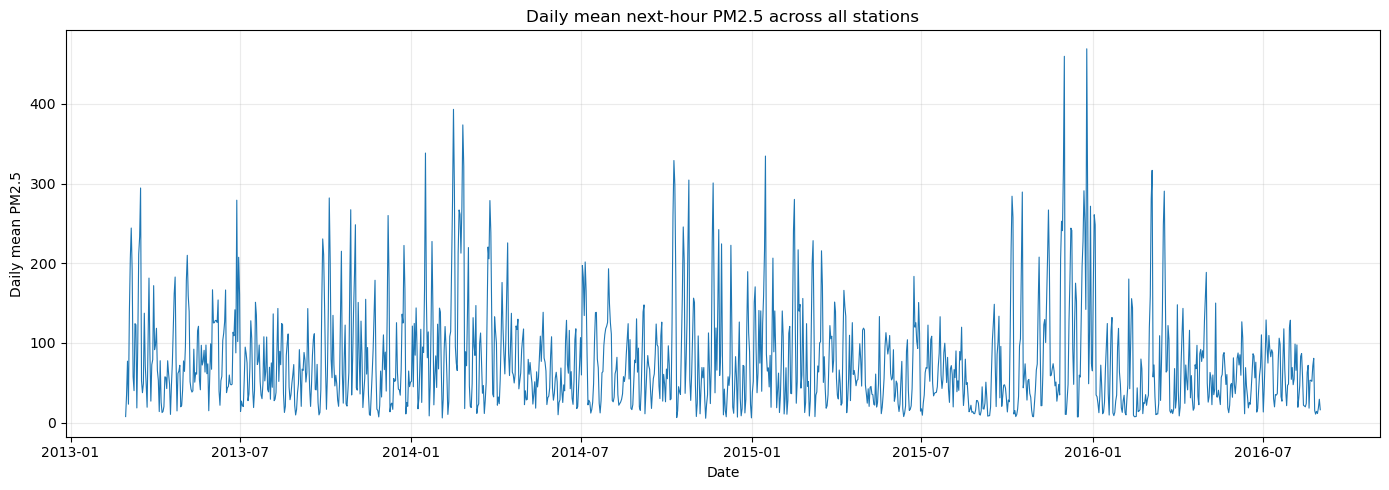

In [21]:
# Daily average target across all stations
daily = (
    eda.set_index("observation_timestamp")[target]
    .resample("D")
    .mean()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily.index, daily.values, linewidth=0.8)
ax.set_title("Daily mean next-hour PM2.5 across all stations")
ax.set_xlabel("Date")
ax.set_ylabel("Daily mean PM2.5")
plt.tight_layout()
plt.show()

### Interpretation

- Pollution exhibits both seasonality and short-lived spikes.
- The series is clearly non-stationary over the full training period: the local mean and variance change through time.
- This reinforces the need for **time-aware validation**.
- Rolling and lagged station-level features should help capture short-run state, while calendar/weather variables help with slower seasonal structure.

## 13. Extreme pollution events

In [22]:
# Extreme-event rates
thresholds = [100, 150, 200, 300, 500]
extreme_table = pd.DataFrame({
    "threshold": thresholds,
    "count": [(eda[target] >= x).sum() for x in thresholds],
    "pct_of_train": [(eda[target] >= x).mean() * 100 for x in thresholds],
})
display(extreme_table)

q = eda[target].quantile([0.90, 0.95, 0.99, 0.995, 0.999, 1.0])
display(q.to_frame("PM2_5_next_hour"))

,threshold,count,pct_of_train
0,100,100975,27.974
1,150,52231,14.470
2,200,28028,7.765
3,300,7631,2.114
4,500,672,0.186


,PM2_5_next_hour
0.900,179.000
0.950,235.000
0.990,354.000
0.995,409.000
0.999,551.000
1.000,999.000


### Interpretation

High values should not automatically be treated as erroneous outliers. They are part of the forecasting target and may correspond to genuine severe pollution episodes. For competition performance, model residuals should be inspected separately for normal and extreme regimes because high-PM2.5 periods can dominate squared error.

## 14. How fast does PM2.5 change?

,next_minus_current
count,"360,954.000"
mean,0.053
std,21.002
min,-628.000
1%,-66.000
5%,-26.000
25%,-5.000
50%,0.000
75%,6.000
95%,23.000


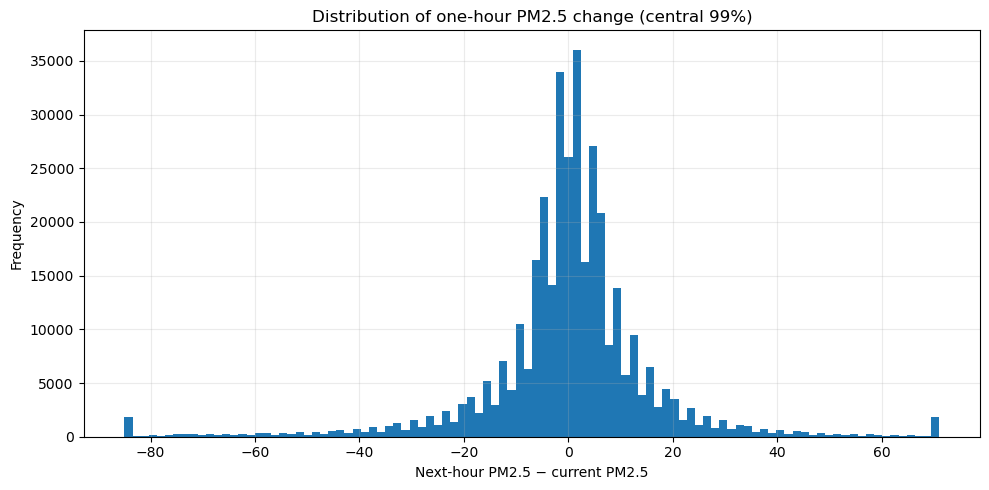

In [23]:
# Change from current to next hour
delta = eda[target] - eda["current_PM2_5"]

display(delta.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame("next_minus_current"))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(delta.dropna().clip(lower=delta.quantile(0.005), upper=delta.quantile(0.995)), bins=100)
ax.set_title("Distribution of one-hour PM2.5 change (central 99%)")
ax.set_xlabel("Next-hour PM2.5 − current PM2.5")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

### Interpretation

Most one-hour changes are relatively small compared with the full target range, which explains why persistence is so strong. The highest-value modelling opportunity is to identify situations where PM2.5 changes sharply. Features describing wind, co-pollutants, weather, time and recent lags can help predict those departures from the current value.

## 15. Train–test distribution shift

Because the test set occurs later in time and covers a different seasonal window, its feature distributions can differ from training. We compare mean, median and a standardized mean difference (SMD).

A large absolute SMD suggests a material distribution shift.

In [24]:
# Numeric train-test shift
shared_numeric = [
    c for c in test.select_dtypes(include=np.number).columns
    if c in train.columns and c not in ["year", "month", "day", "hour"]
]

rows = []
for c in shared_numeric:
    tr = train[c].dropna()
    te = test[c].dropna()
    pooled_std = np.sqrt((tr.var() + te.var()) / 2)
    smd = (te.mean() - tr.mean()) / pooled_std if pooled_std > 0 else np.nan
    rows.append({
        "feature": c,
        "train_mean": tr.mean(),
        "test_mean": te.mean(),
        "train_median": tr.median(),
        "test_median": te.median(),
        "SMD": smd,
        "abs_SMD": abs(smd) if pd.notna(smd) else np.nan,
    })

shift = pd.DataFrame(rows).sort_values("abs_SMD", ascending=False)
display(shift)

,feature,train_mean,test_mean,train_median,test_median,SMD,abs_SMD
7,PRES,"1,009.757","1,017.976","1,009.000","1,018.500",0.879,0.879
6,TEMP,14.473,6.585,16.100,4.200,-0.761,0.761
5,O3,60.843,32.502,50.000,20.000,-0.594,0.594
8,DEWP,3.283,-3.342,4.500,-5.400,-0.510,0.510
4,CO,"1,184.508","1,547.714",900.000,"1,100.000",0.276,0.276
3,NO2,49.488,59.021,43.000,54.000,0.261,0.261
2,SO2,16.376,12.089,8.000,6.000,-0.228,0.228
0,current_PM2_5,77.991,92.217,55.000,59.000,0.161,0.161
1,PM10,103.524,112.473,83.000,82.000,0.090,0.090
10,WSPM,1.735,1.673,1.400,1.400,-0.050,0.050


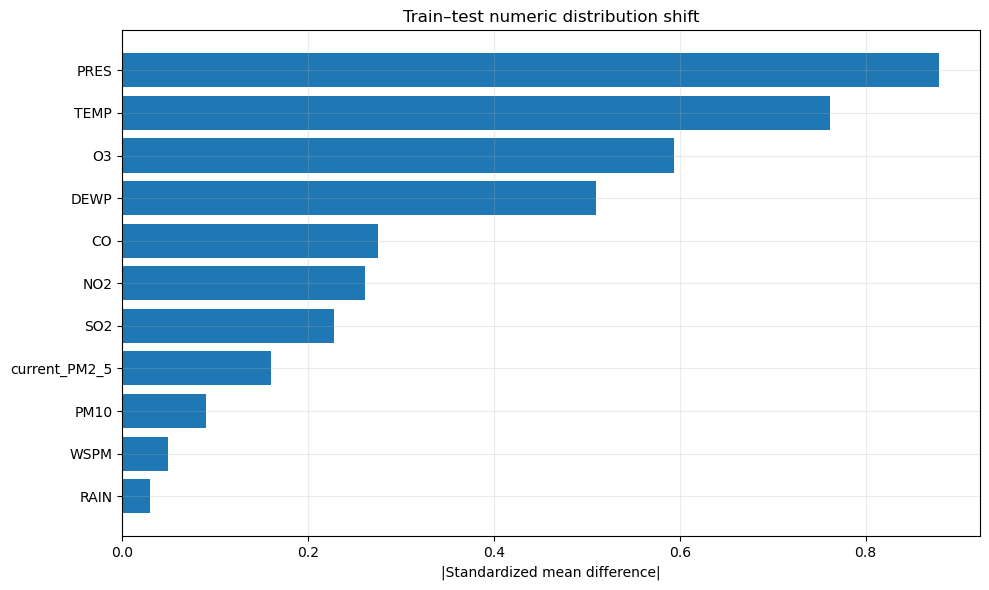

In [25]:
shift_plot = shift.sort_values("abs_SMD")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(shift_plot["feature"], shift_plot["abs_SMD"])
ax.set_title("Train–test numeric distribution shift")
ax.set_xlabel("|Standardized mean difference|")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Interpretation

- Train and test should not be assumed to be identically distributed because they occupy different dates and seasons.
- Features with larger standardized mean differences deserve special attention during validation.
- This is another reason a random split is inappropriate: random splitting mixes seasonal regimes and makes the validation set look artificially similar to training.
- A strong local validation scheme should imitate the Kaggle setup by holding out the latest contiguous block of training dates.

## 16. Missingness by station

In [26]:
# Missingness can be station-specific
sensor_cols = ["current_PM2_5", "PM10", "SO2", "NO2", "CO", "O3",
               "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

station_missing = (
    train.groupby("station")[sensor_cols]
    .apply(lambda x: x.isna().mean() * 100)
)

display(station_missing.round(2))

,current_PM2_5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
station,,,,,,,,,,,
Aotizhongxin,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Changping,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Dingling,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Dongsi,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Guanyuan,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Gucheng,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Huairou,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Nongzhanguan,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Shunyi,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


### Interpretation

Sensor failures are not necessarily random. If some stations have systematically higher missingness, global mean/median imputation may blur station-specific behaviour. Candidate strategies should be validated rather than assumed:

1. model-native missing-value handling;
2. station-specific median imputation;
3. safe past-only temporal filling/interpolation;
4. explicit binary missing-indicator features.

## 17. Leakage-safe validation design

### Recommended local split

A good first validation is a **contiguous final block** from the training set, for example the final 3–6 months. A stronger estimate can use rolling-origin / walk-forward folds.

Never create lagged or rolling features before sorting by **station + timestamp**, and never allow a rolling calculation to include future rows.

In [27]:
# Example chronological validation split
cutoff = train["observation_timestamp"].max() - pd.DateOffset(months=6)

train_fold = train[train["observation_timestamp"] < cutoff].copy()
valid_fold = train[train["observation_timestamp"] >= cutoff].copy()

print("Cutoff:", cutoff)
print("Development train:", train_fold["observation_timestamp"].min(),
      "to", train_fold["observation_timestamp"].max(), train_fold.shape)
print("Validation:", valid_fold["observation_timestamp"].min(),
      "to", valid_fold["observation_timestamp"].max(), valid_fold.shape)

Cutoff: 2016-02-29 22:00:00
Development train: 2013-03-01 00:00:00 to 2016-02-29 21:00:00 (309252, 20)
Validation: 2016-02-29 22:00:00 to 2016-08-31 22:00:00 (51702, 20)


In [28]:
# Persistence baseline specifically on the chronological validation period
baseline_valid = valid_fold[["current_PM2_5", target]].dropna()

valid_mae = np.mean(np.abs(baseline_valid[target] - baseline_valid["current_PM2_5"]))
valid_rmse = np.sqrt(np.mean((baseline_valid[target] - baseline_valid["current_PM2_5"]) ** 2))

print(f"Chronological validation persistence MAE:  {valid_mae:.3f}")
print(f"Chronological validation persistence RMSE: {valid_rmse:.3f}")

Chronological validation persistence MAE:  9.301
Chronological validation persistence RMSE: 16.579


### Interpretation

Use this persistence score as the **minimum bar** for modelling experiments. Keep the same chronological split while comparing feature sets and algorithms; otherwise improvements may reflect an easier validation set rather than a genuinely stronger model.

## 18. Recommended feature engineering after EDA

The following features are strongly motivated by the data structure:

**Lag / momentum features — computed separately within each station**
- `PM2_5_lag_1`, `lag_2`, `lag_3`, `lag_6`, `lag_12`, `lag_24`
- pollutant lags for PM10 / CO / NO2 / O3
- one-hour and multi-hour differences
- rolling means / medians / standard deviations over 3, 6, 12 and 24 hours
- rolling min / max and trend/slope features

**Calendar features**
- hour, weekday, month
- cyclic hour/month encodings where useful
- season
- possibly holiday information if external-data rules permit it

**Meteorological features**
- wind direction as categorical
- wind components if directions are mapped to angles
- temperature–dew-point spread
- station × wind interactions
- rain indicator
- pressure and weather-change lags

**Missingness features**
- one binary indicator per sensor with meaningful missingness
- past-only time since last valid sensor reading, if useful

> **Leakage rule:** every lag/rolling feature for a row at time `t` must depend only on data available at or before `t`, never on `t+1` or later.

## 19. Insights for modelling

1. **This is a temporal forecasting task.** Test begins directly after train; use chronological validation.
2. **Persistence is extremely strong.** `current_PM2_5` has ~0.968 correlation with next-hour PM2.5 and is the key baseline.
3. **Co-pollutants matter.** PM10, CO and NO2 provide strong additional signal.
4. **Weather matters nonlinearly.** Wind speed is negatively associated with PM2.5; temperature, dew point and pressure show nonlinear patterns.
5. **Station identity matters.** Pollution levels differ across the 12 locations, so lag/rolling features must be station-specific.
6. **Seasonality is material.** Hour and month show systematic variation, while test covers a future seasonal regime.
7. **The target is heavily right-skewed.** Severe pollution episodes are genuine and can strongly influence RMSE-like metrics.
8. **Missingness is nontrivial and differs between train and test.** Imputation must be leakage-safe and validated.
9. **Best next modelling direction:** start with the persistence baseline, then test CatBoost / LightGBM / XGBoost-style gradient boosting using current measurements + station/time/weather + safe lag/rolling features.
10. **Evaluate regime-specific errors.** Compare normal periods with high-pollution episodes and inspect performance by station.


## EDA findings carried into modelling

The modelling strategy follows directly from the exploratory analysis:

1. **Persistence baseline:** current PM2.5 is the strongest single predictor, so `current_PM2_5` is used as the reference one-hour-ahead forecast.
2. **Temporal validation:** because the competition test period occurs after the training period, validation must also be out-of-time.
3. **Station-specific history:** lagged and rolling features must be created within station to avoid mixing measurements between monitoring locations.
4. **Momentum features:** most one-hour changes are relatively small, so the difficult cases are rapid rises and falls. Difference and trend features are designed to capture these transitions.
5. **Co-pollutant signal:** PM10, CO, NO2, SO2 and O3 are retained because they contain additional information about the pollution state.
6. **Weather context:** wind, temperature, dew point and pressure show useful relationships with PM2.5, including nonlinear effects.
7. **Extreme-event retention:** severe pollution observations are kept because RMSE places especially high penalty on large prediction errors.
8. **Distribution shift:** validation is designed to mimic future-period generalisation rather than IID interpolation.

## Limitations of the EDA

- Pearson correlation measures only linear association and may understate nonlinear predictive relationships.
- Associations observed in EDA should not be interpreted as causal effects.
- The test period covers a later seasonal regime than much of training, so some feature distributions may shift over time.
- Station identity is available, but richer geographic or emissions metadata are not included in the supplied competition files.
- Extreme PM2.5 values are retained because they may represent genuine severe pollution episodes; however, without external sensor-quality metadata, the EDA cannot independently verify every extreme observation.
- EDA is descriptive. Final feature usefulness must be established through out-of-time RMSE rather than visual association alone.